### 0. Import and initialize db file

In [1]:
import qcodes as qc
from qcodes.dataset.data_set import load_by_id
import matplotlib.pyplot as plt
from qcodes import initialise_or_create_database_at
import numpy as np
import pandas as pd

import os
from typing import Set, Dict, Tuple


In [ ]:
db_file_path = r"test.db"
initialise_or_create_database_at(db_file_path)

###  1. load a dataset by ID number


In [117]:
# get dataset (ds) by id
run_ID = 3
ds = load_by_id(run_ID)

# convert ds to xarray (the xaaray can turn into numpy array)
ds_xarray = ds.to_xarray_dataset()

### 2. get parameters

In [118]:
ds.get_parameters() # extract parameters in the experiment id you load

[ParamSpec('keithley_A_smua_volt', 'numeric', 'Voltage', 'V', inferred_from=[], depends_on=[]),
 ParamSpec('keithley_A_smua_curr', 'numeric', 'Current', 'A', inferred_from=[], depends_on=['keithley_A_smua_volt'])]

In [119]:
ds.dependent_parameters

(ParamSpecBase('keithley_A_smua_curr', 'numeric', 'Current', 'A'),)

In [120]:
for par in ds.get_parameters():
    if len(par.depends_on_) != 0:
        print(f'parameter: [{par.name}], depends on: {par.depends_on_}')

parameter: [keithley_A_smua_curr], depends on: ['keithley_A_smua_volt']


In [121]:
# 4-1. auto get x or xy parameter names
for par in ds.get_parameters():
    if par.depends_on != '':
        # check how the len of depends_on_.
        # 1 = 1D data
        # 1 = 2D data
        
        # 1D data,
        if len(par.depends_on_)==1:
            x_name = par.depends_on
            par_dim = 1
        # 2D data,
        elif len(par.depends_on_)==2:
            x_name = par.depends_on_[0]
            y_name = par.depends_on_[1]
            par_dim = 2
        break

# print plotting parameter name (then choose one to type it in par_name to set as y axis)
for par in ds.dependent_parameters:
    print(par.name)

keithley_A_smua_curr


### 3. get data and plot the data

In [122]:
# get data from the xarray
par_name = 'keithley_A_smua_curr'
ds_xarray[par_name].to_numpy()

array([-1.19209e-14, -2.72989e-12,  3.69549e-13, -5.72205e-13,
       -2.96831e-12,  3.45707e-13, -1.65701e-12, -2.19345e-12,
        7.27177e-13, -1.66893e-12, -1.85966e-12,  8.82149e-13,
       -1.04904e-12, -1.93119e-12,  1.14441e-12, -1.71661e-12,
       -1.53780e-12,  7.86781e-13, -1.58548e-12, -1.96695e-12,
        8.46386e-13, -7.51019e-13, -2.18153e-12,  5.96046e-13,
       -7.62939e-13, -2.07424e-12,  6.67572e-13, -1.56164e-12,
       -1.85966e-12,  1.04904e-12, -1.38283e-12, -1.99080e-12,
        8.70228e-13, -8.46386e-13, -2.07424e-12,  8.34465e-13,
       -8.82149e-13, -1.94311e-12,  9.17912e-13, -1.56164e-12,
       -1.41859e-12,  9.89437e-13, -2.20537e-12, -6.31809e-13,
        6.55651e-13, -2.31266e-12, -5.96046e-14,  4.76837e-14,
       -2.55108e-12, -2.38419e-14])

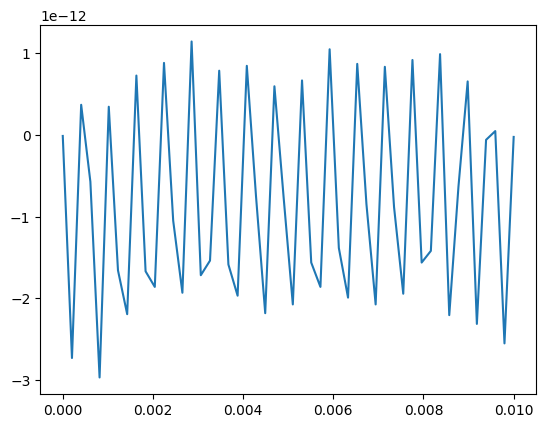

In [123]:
# 5. define which par to plot

par_name = 'keithley_A_smua_curr'  # you need to manually type your parameter name in the last cell you print


# 5. get x axis data

# 1D data
if par_dim == 1:
    x = ds_xarray[x_name].to_numpy()
    y = ds_xarray[par_name].to_numpy()
    # plot 1D data
    plt.plot(x,y)

# 2D data
elif par_dim == 2:
    x = ds_xarray[x_name].to_numpy()
    y = ds_xarray[y_name].to_numpy()
    z = ds_xarray[par_name].to_numpy()
    mesh = plt.pcolormesh(x, y, z, shading='auto', cmap='viridis')
    plt.colorbar(mesh, label=par.unit)

### 4. optional: make the plot better (get more info from ds)

In [ ]:
import qcodes as qc
from qcodes.dataset.data_set import load_by_id
import matplotlib.pyplot as plt
from qcodes import initialise_or_create_database_at
import numpy as np
import pandas as pd

import os
from typing import Set, Dict, Tuple

# import helper functions
from utils import get_optimal_data_and_unit, get_title_string
from utils import QCoDeSDatasetWrapper as super_load_by_id


In [ ]:
db_file_path = r"test.db"
initialise_or_create_database_at(db_file_path)

In [11]:
super_ds = super_load_by_id(550)

→ Parsed 2D parameter: amp_meas, depends on: ['energy', 'detuning']


In [19]:
super_ds.amp_meas.data

array([[0.00065965, 0.00069864, 0.00070566, ..., 0.00083364, 0.00083117,
        0.00083807],
       [0.00066227, 0.00070652, 0.00071406, ..., 0.00083068, 0.00083468,
        0.00083433],
       [0.00066738, 0.00071225, 0.00071722, ..., 0.00083311, 0.00083663,
        0.00083883],
       ...,
       [0.00076606, 0.00076563, 0.00077192, ..., 0.00088326, 0.00086764,
        0.00085382],
       [0.00076355, 0.00077142, 0.00076616, ..., 0.00086465, 0.00085375,
        0.00084753],
       [0.00076851, 0.00076785, 0.00076701, ..., 0.000854  , 0.00084349,
        0.00083623]])

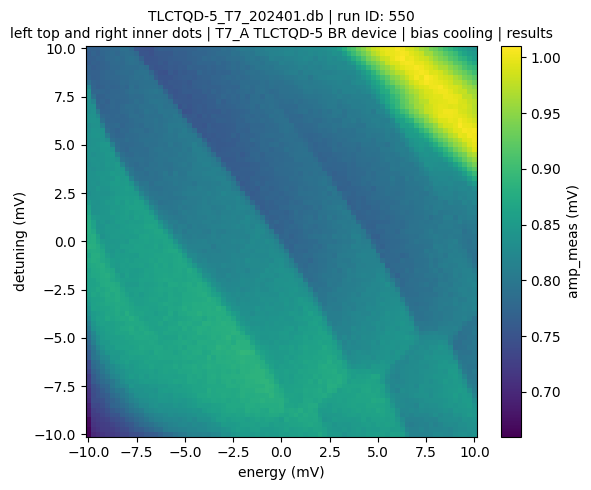

In [ ]:
par = super_ds.amp_meas

# 1D data
if par.dim == 1:
    # get data
    x = par.x.data
    par_data = par.data

    # get name, unit, label
    x_name = par.x.name
    x_unit = par.x.unit
    x_label = par.x.label
    
    par_name = par.name
    par_unit = par.unit
    par_label = par.label

    # update data and unit to optimal (opt) scale
    x_opt, x_opt_unit = get_optimal_data_and_unit(x, x_unit)
    par_data_opt, par_opt_unit = get_optimal_data_and_unit(par_data, par_unit)

    # plot 1D data
    plt.figure(figsize=(7,5))
    plt.plot(x_opt,par_data_opt)
    plt.xlabel(f'{x_name}: {x_label} ({x_opt_unit})')
    plt.ylabel(f'{par_name}: {par_label} ({par_opt_unit})')
    
    title_string = get_title_string(super_ds.dataset)

    plt.grid()
    plt.title(title_string, fontsize = 10)

# 2D data
elif par.dim == 2:
    # get data
    x = par.x.data
    y = par.y.data
    par_data = par.data

    # get name, unit, label
    x_name = par.x.name
    x_unit = par.x.unit
    x_label = par.x.label

    y_name = par.y.name
    y_unit = par.y.unit
    y_label = par.y.label
    
    par_name = par.name
    par_unit = par.unit
    par_label = par.label

    # update data and unit to optimal (opt) scale
    x_opt, x_opt_unit = get_optimal_data_and_unit(x, x_unit)
    y_opt, y_opt_unit = get_optimal_data_and_unit(y, y_unit)

    par_data_opt, par_opt_unit = get_optimal_data_and_unit(par_data, par_unit)
    
    plt.figure(figsize=(6,5))
    mesh = plt.pcolormesh(x_opt, y_opt, par_data_opt, shading='auto', cmap='viridis')
    plt.colorbar(mesh, label=f'{par_name} ({par_opt_unit})')
    plt.xlabel(f'{x_name} ({x_opt_unit})')
    plt.ylabel(f'{y_name} ({y_opt_unit})')
    
    title_string = get_title_string(super_ds.dataset)

    plt.title(title_string, fontsize = 10)
    plt.tight_layout()